# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print(df.isnull().mean().sort_values(ascending=False))

# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ["alive", "who", "adult_male", "class", "deck", "embark_town", "alone"]
leaky = [c for c in leaky if c in df.columns]
df = df.drop(columns=leaky)

print("Các cột còn lại:", list(df.columns))

deck           0.772166
age            0.198653
embarked       0.002245
embark_town    0.002245
sex            0.000000
pclass         0.000000
survived       0.000000
fare           0.000000
parch          0.000000
sibsp          0.000000
class          0.000000
adult_male     0.000000
who            0.000000
alive          0.000000
alone          0.000000
dtype: float64
Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

Cột `alive` chỉ là biến `survived` được viết lại dưới dạng chữ ("yes"/"no") thay vì số (1/0) — hai cột này mang **chính xác cùng một thông tin**. Nếu giữ `alive` lại làm đặc trưng đầu vào, mô hình chỉ cần học một quy tắc tầm thường: "yes" → 1, "no" → 0, để đạt accuracy gần như 100%. Nhưng đó không phải là mô hình đang *dự đoán* khả năng sống sót từ các đặc điểm hành khách (tuổi, giới tính, hạng vé...) — nó đang *đọc lại đáp án* đã cho sẵn. Đây chính là **data leakage**: thông tin về nhãn (target) bị rò vào tập đặc trưng (features), khiến kết quả đánh giá trên giấy rất đẹp nhưng khi triển khai thực tế (lúc chưa biết ai sống ai chết) mô hình sẽ hoàn toàn vô dụng vì làm gì có sẵn cột `alive` để tra.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print("Số dòng, số cột:", df.shape)
print("Biến mục tiêu (target): 'survived' (1 = sống sót, 0 = không sống sót)\n")

df.info()

print("\n--- describe() cho biến số ---")
display(df.describe())

print("\n--- describe(include='object') cho biến phân loại ---")
display(df.describe(include="object"))

Số dòng, số cột: (891, 8)
Biến mục tiêu (target): 'survived' (1 = sống sót, 0 = không sống sót)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB

--- describe() cho biến số ---


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- describe(include='object') cho biến phân loại ---


/tmp/ipykernel_534/826213265.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include="object"))


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

- **Biến số (numeric):** `survived` (nhị phân 0/1, thực chất là target), `pclass` (số nhưng mang tính thứ tự 1<2<3), `age`, `sibsp`, `parch`, `fare`.
- **Biến phân loại (categorical):** `sex`, `embarked`.

Lưu ý: `pclass` tuy được lưu dưới dạng số nhưng về bản chất là **biến thứ tự (ordinal)** — không nên coi nó như một biến liên tục thông thường khi phân tích tương quan tuyến tính, dù trong tiền xử lý ta có thể giữ nguyên (passthrough) vì thứ tự 1 < 2 < 3 đã có ý nghĩa (hạng vé giảm dần).

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100

missing_table = pd.DataFrame({
    "so_luong_thieu": missing_count,
    "phan_tram_thieu": missing_pct.round(2)
})
missing_table = missing_table[missing_table["so_luong_thieu"] > 0].sort_values(
    "phan_tram_thieu", ascending=False
)
display(missing_table)

,so_luong_thieu,phan_tram_thieu
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| `age` | ~20% | Điền **median** | Tỷ lệ thiếu vừa phải (không quá cao để phải bỏ cột); `age` có phân phối hơi lệch và có outlier (khách rất lớn tuổi), nên median bền vững hơn mean, tránh bị outlier kéo lệch giá trị điền vào. |
| `embarked` | rất thấp (~0.2%) | Điền **mode** (giá trị xuất hiện nhiều nhất) | Đây là biến phân loại nên không thể tính mean/median; tỷ lệ thiếu quá nhỏ (chỉ 2 dòng) nên điền mode gần như không ảnh hưởng gì tới phân phối tổng thể. |

*(Cột `deck` thiếu ~77% đã được loại bỏ hoàn toàn ở Task 1 vì thiếu quá nhiều để có thể điền một cách đáng tin cậy.)*

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s = s.dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lower) | (s > upper)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z = np.abs(stats.zscore(s))
    return (z > nguong).sum()

for col in ["age", "fare"]:
    n_iqr = dem_outlier_iqr(df[col])
    n_z = dem_outlier_zscore(df[col])
    print(f"{col}: outlier theo IQR = {n_iqr} ({n_iqr/df[col].notna().sum()*100:.1f}%), "
          f"outlier theo Z-score = {n_z} ({n_z/df[col].notna().sum()*100:.1f}%)")

age: outlier theo IQR = 11 (1.5%), outlier theo Z-score = 2 (0.3%)
fare: outlier theo IQR = 116 (13.0%), outlier theo Z-score = 20 (2.2%)


**Trả lời 4 (quyết định với outlier của `fare`):**

Các outlier của `fare` (vé rất đắt, ví dụ trên ~$100-500) **nên được giữ lại**, không loại bỏ. Đây không phải lỗi nhập liệu mà là **hiện tượng thật**: vé hạng nhất (pclass = 1), đặc biệt vé của các gia đình giàu có hoặc mua nhiều suite, có giá cao hơn hẳn phần còn lại một cách hợp lý. Loại bỏ các dòng này sẽ làm mất đi thông tin quan trọng — vì giá vé tương quan khá mạnh với khả năng sống sót (hành khách hạng sang thường ở gần boong trên, dễ tiếp cận xuồng cứu sinh hơn). Thay vì xóa, ta xử lý ảnh hưởng của outlier bằng cách chọn **RobustScaler** (dùng median/IQR thay vì mean/std) khi scaling ở Task 7, để các giá trị cực đoan không làm méo thang đo của toàn bộ cột.

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

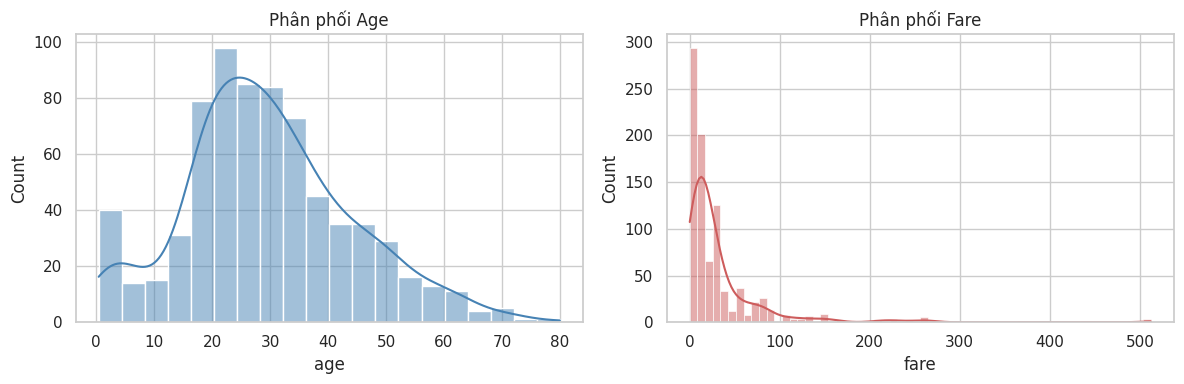

In [7]:
# TODO 5a: Histogram age & fare
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["age"].dropna(), kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Phân phối Age")
sns.histplot(df["fare"].dropna(), kde=True, ax=axes[1], color="indianred")
axes[1].set_title("Phân phối Fare")
plt.tight_layout()
plt.show()

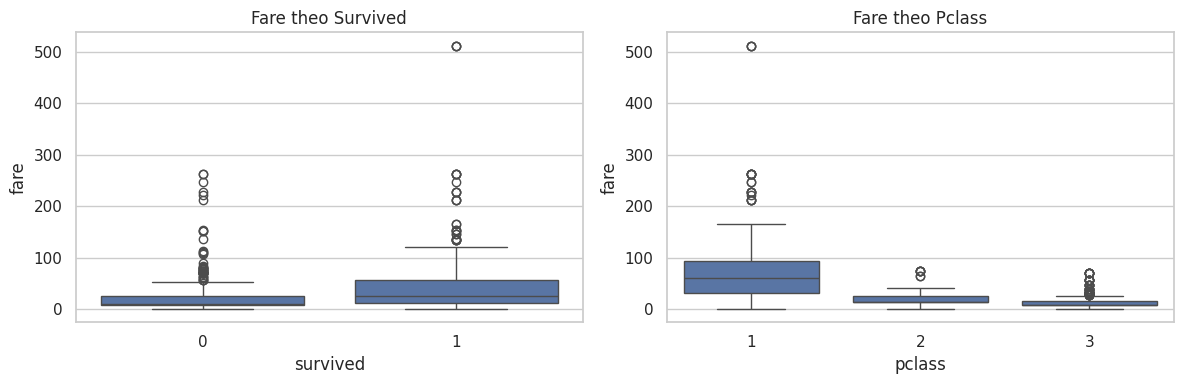

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x="survived", y="fare", ax=axes[0])
axes[0].set_title("Fare theo Survived")
sns.boxplot(data=df, x="pclass", y="fare", ax=axes[1])
axes[1].set_title("Fare theo Pclass")
plt.tight_layout()
plt.show()

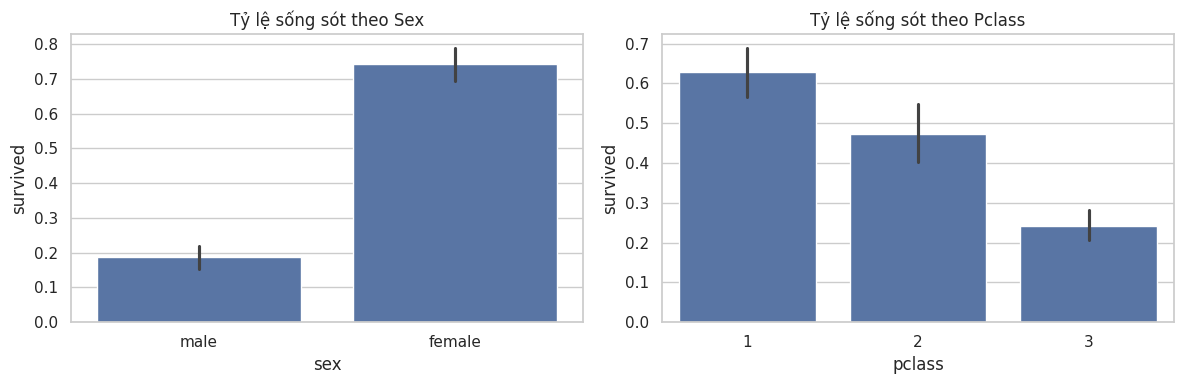

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x="sex", y="survived", ax=axes[0])
axes[0].set_title("Tỷ lệ sống sót theo Sex")
sns.barplot(data=df, x="pclass", y="survived", ax=axes[1])
axes[1].set_title("Tỷ lệ sống sót theo Pclass")
plt.tight_layout()
plt.show()

print(df.groupby("sex")["survived"].mean())
print(df.groupby("pclass")["survived"].mean())

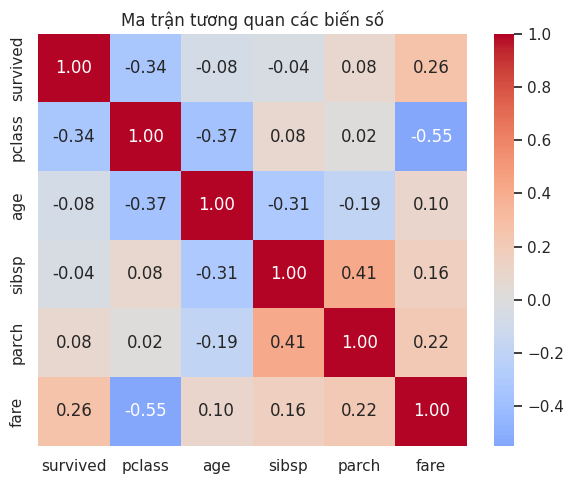

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(6, 5))
sns.heatmap(df.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Ma trận tương quan các biến số")
plt.tight_layout()
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- **Histogram:** `age` xấp xỉ phân phối chuẩn, hơi lệch phải nhẹ, tập trung nhiều ở khoảng 20-40 tuổi. `fare` lệch phải rất mạnh (right-skewed) — đa số vé rẻ (dưới ~$30) nhưng có một số ít vé rất đắt kéo dài đuôi phân phối, đúng như dự đoán ở Task 4.
- **Boxplot:** Nhóm `survived = 1` có trung vị `fare` cao hơn rõ rệt so với nhóm `survived = 0`, và nhóm `pclass = 1` có `fare` cao hơn hẳn (kèm nhiều outlier) so với `pclass = 2, 3` — cho thấy giá vé/hạng vé liên quan mật thiết đến sống sót.
- **Bar survival:** Nữ giới có tỷ lệ sống sót cao hơn nam giới rất nhiều (khoảng 74% so với 19%, chênh hơn 50 điểm %); hành khách `pclass = 1` sống sót nhiều hơn hẳn `pclass = 3` (khoảng 63% so với 24%). Cả hai đều phản ánh chính sách ưu tiên "phụ nữ và trẻ em trước, hạng nhất trước" khi lên xuồng cứu sinh.
- **Heatmap:** `fare` và `pclass` tương quan âm khá mạnh (~-0.55, hạng vé càng thấp số thì giá càng cao), phù hợp logic. `survived` tương quan dương với `fare` (~0.26) và âm với `pclass` (~-0.34) — hai đặc trưng liên quan tới "tiền/hạng vé" có tương quan rõ nhất với sống sót trong nhóm biến số.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=["survived"])
y = df["survived"]

X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=0.15/0.85, stratify=y_tmp, random_state=42
)

print("Train/Val/Test shape:", X_train.shape, X_val.shape, X_test.shape)
print("Tỷ lệ survived - train:", y_train.mean().round(3))
print("Tỷ lệ survived - val:  ", y_val.mean().round(3))
print("Tỷ lệ survived - test: ", y_test.mean().round(3))

Train/Val/Test shape: (623, 7) (134, 7) (134, 7)
Tỷ lệ survived - train: 0.384
Tỷ lệ survived - val:   0.388
Tỷ lệ survived - test:  0.381


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler()),
])
pipe_cat = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocess = ColumnTransformer([
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols),
])

preprocess.fit(X_train)               # fit CHỈ trên train
X_train_t = preprocess.transform(X_train)
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)

print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

Các bước tiền xử lý (điền median/mode, tính min-max hay IQR để scale, danh sách các category để one-hot encode) đều là những **phép "học tham số" từ dữ liệu**. Nếu `fit` trên toàn bộ dataset (gồm cả val/test) rồi mới chia tập, thì median của `age`, IQR của `fare`, hay danh sách category của `embarked`... đã "nhìn thấy" cả những mẫu lẽ ra phải hoàn toàn xa lạ với mô hình (tập test mô phỏng dữ liệu tương lai chưa biết trước). Điều này khiến tập test không còn thực sự độc lập, kết quả đánh giá sẽ **lạc quan giả tạo (optimistic bias)** so với khi triển khai thực tế. Bằng cách `fit` preprocessor chỉ trên `X_train` rồi `transform` cho val/test, ta đảm bảo mọi tham số biến đổi chỉ đến từ tập huấn luyện — giống hệt tình huống thực tế khi mô hình gặp dữ liệu mới hoàn toàn chưa từng thấy.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print(df["survived"].value_counts())
print(df["survived"].value_counts(normalize=True).round(3))

survived
0    549
1    342
Name: count, dtype: int64
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


**Trả lời 8:**

1. Có, `survived` **mất cân bằng ở mức nhẹ đến trung bình**: khoảng 62% không sống sót (0) và 38% sống sót (1) — không phải mất cân bằng cực đoan (như 99/1) nhưng đủ để cần cẩn trọng khi chọn metric.
2. Nếu chỉ nhìn Accuracy, một mô hình "ngu" luôn đoán "không sống sót" (lớp đa số) cũng đạt Accuracy ~62% mà không học được gì hữu ích — dễ đánh lừa người đọc rằng mô hình "tốt" trong khi nó hoàn toàn vô dụng cho việc phát hiện nhóm thiểu số (những người sống sót).
3. Với bài toán Titanic, nên ưu tiên **F1-score** (hoặc xem cả Precision lẫn Recall) thay vì chỉ Accuracy, vì dữ liệu mất cân bằng và ta thường quan tâm đến khả năng mô hình nhận diện đúng nhóm sống sót (lớp thiểu số, quan trọng về mặt phân tích) — F1 cân bằng giữa việc không bỏ sót người sống sót (Recall) và không dự đoán sai quá nhiều người sống sót giả (Precision).

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng tương quan mạnh nhất với `survived` trong nhóm biến số là **`fare`** (tương quan dương ~0.26) và **`pclass`** (tương quan âm ~-0.34); ngoài ra biến phân loại `sex` cho thấy chênh lệch tỷ lệ sống sót rất lớn giữa nam và nữ (~74% vs ~19%), đây thực chất là đặc trưng ảnh hưởng mạnh nhất tổng thể dù không nằm trong ma trận tương quan số.
2. Cột thiếu nhiều nhất ban đầu là **`deck`** (~77%) — đã bị **loại bỏ hoàn toàn** ở Task 1 vì tỷ lệ thiếu quá cao để điền một cách tin cậy. Trong các cột giữ lại, `age` thiếu nhiều nhất (~20%) và được xử lý bằng **điền median** trong pipeline.
3. Biến mục tiêu **mất cân bằng nhẹ** (~62% không sống sót / 38% sống sót). Điều này khiến Accuracy đơn thuần dễ gây hiểu lầm, nên khi đánh giá mô hình cần ưu tiên thêm Precision/Recall/F1.
4. Các biến số liên tục (`age`, `sibsp`, `parch`, `fare`) cần **scaling** (dùng RobustScaler do có outlier ở `fare`) vì các thuật toán dựa trên khoảng cách hoặc gradient nhạy cảm với thang đo khác nhau. Các biến phân loại (`sex`, `embarked`) cần **encoding** (OneHotEncoder) vì mô hình chỉ hiểu số, không hiểu chuỗi ký tự; riêng `pclass` tuy là số nhưng mang tính thứ tự nên được giữ nguyên (passthrough) thay vì one-hot.
5. Điều bất ngờ/thú vị: chênh lệch tỷ lệ sống sót giữa nam và nữ lớn hơn nhiều so với dự đoán ban đầu (hơn 50 điểm phần trăm) — cho thấy chính sách "phụ nữ và trẻ em trước" trong thảm họa Titanic có ảnh hưởng cực kỳ rõ rệt lên dữ liệu, mạnh hơn cả ảnh hưởng của tiền bạc (giá vé/hạng vé).

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

             family_size  survived
family_size     1.000000  0.016639
survived        0.016639  1.000000


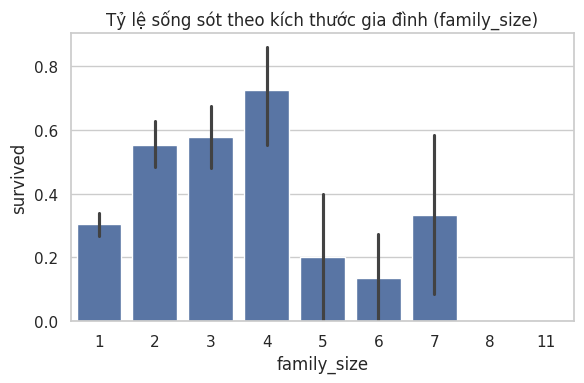

In [14]:
# (tùy chọn) code cho phần Bonus — Feature engineering: family_size
df_bonus = df.copy()
df_bonus["family_size"] = df_bonus["sibsp"] + df_bonus["parch"] + 1

print(df_bonus[["family_size", "survived"]].corr())

plt.figure(figsize=(6, 4))
sns.barplot(data=df_bonus, x="family_size", y="survived")
plt.title("Tỷ lệ sống sót theo kích thước gia đình (family_size)")
plt.tight_layout()
plt.show()

# Nhận xét: gia đình quy mô vừa (2-4 người) có xu hướng sống sót cao hơn
# người đi một mình (family_size=1) hoặc gia đình quá đông (>=5),
# có thể vì đi một mình khó được hỗ trợ, còn gia đình quá đông khó di chuyển
# và tập hợp đủ người kịp lúc lên xuồng cứu sinh.

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
